<center><b>EE (P) 533 Spring 2026<br>
Analog Circuits for Sensor Systems<br>
University of Washington Electrical & Computer Engineering</b></center>


<b>Instructor: Mahmood Hameed<br>
Design Project Phase 1: Strain Gage Low-Noise Signal Conditioning<br>
Due Monday, June 1st (Submit on Canvas as a Jupyter Notebook)</b> 

The final project for this course involves the design of the signal conditioning electronics for a strain gage sensor. Your design will amplify amplifier and filter a strain gage signal from a Wheatstone bridge. The project goals are:

 - Translating application specifications (e.g. dynamic range of a sensor output) into circuit specifications
 - Assessing different noise sources and their impact in acheiving performance targets (e.g. SNR)
 - Choosing components for gain and filtering to optimize for SNR, power dissipation, and cost
 - Evaluating the impact of manufacturing variations on performance goals, and and selecting components that achieve the optimal balance between performance, component availability, and cost

The project will consist of two phases. At the end of Phase 1 you are asked to submit a Jupyter Notebook providing details of your design choices and the results of any relevant analyses (e.g. circuit analysis, Python scripts, or simulation results). 


| Item               | Due date | Proportion of project grade |
| :---------------- | :------ | :-------------------------: |
| Phase 1 submission | March 6 | 50 % |
| Phase 2 submission | March 17 | 50 % |

__System Architecture__

The noise performance of a sensor system is typically determined by the noise density of the front-end electronics (opamps and resistors) and the bandwidth of the signal path. Sensors may also contribute noise, as is the case for a Wheatstone bridge used the convert the change in resistance of a strain gage to a differential voltage. 

<center><img src="EE538_Project_Architecture.png" width=800></center>
<br>
<center><b> Figure 1. Strain gage signal condition architecture.</center>

__Fig 1.__ show the sensor signal conditioning “front-end” architecture for a strain gage sensor. The differential output voltage of the strain gage is amplified by the instrumentation amplifier and converted to a single-ended voltage. The output of the amplifier is fed to a lowpass filter which sets the noise bandwidth of the front-end circuitry. 

The strain gage produces a differential output in response to an applied strain, which results from lengthening or shortening of a conductive element that changes its resistance. These changes in resistance are typically quite small, as the change in length $\Delta L$ relative to the nominal length $L$ is small, on the order of 0.1% (for example).

Strain gage sensors are typically based on the Wheatstone bridge, a network of four resistances with an “excitation voltage” applied across the bridge ($V_{DD}$ in __Fig. 1__). The number of bridge resistances subjected to strain determines the strain gage sensitivity (expressed in mV/V).


__Phase 1__

For the first phase you are to design an instrumentation amplifier to amplify the strain gage signal while adding minimal noise. Filtering will be addressed during Phase 2 $-$ for Phase 1 we will design assuming a signal bandwidth of $10kHz$.  __Fig. 2__ shows the recommended architecture of the instrumentation amplifier. 

<center><img src="EE538_Front_End.png" width=600></center>
<br>
<center><b> Figure 2. Instrumentation amplifier schematic.</center>

| Parameter                            | Specification   | Unit |
| :----------------                    | :------:        | :-------------------------: |
| Supply voltage ($V_{DD}$)            | $5$               | $V$ |
| Peak-to-peak signal amplitude        | $20$              | $mV$ |
| Nominal strain gage resistance ($R$) | $1$               | $k\Omega$ |
| Peak-to-peak output amplitude ($V_{out}$)        | $2$               | $V$ |
| Signal-to-noise ratio                | $\geq 77$         | $dB$ | 
| Signal bandwidth ($f_{sbw}$)         | $10$              | $kHz$ |  
| Input-referred offset     | $\leq 1$              | $mV$ |  
| CMRR                                 | $90$              | $dB$ |
| Power dissipation ($I_{DD} \cdot V_{DD}$) | Optimize   | $mW$ |
| Cost-per-unit (10,000 units)          | Optimize       |$\$$ |

__Recommended design approach__

 - Determine the gain required to meet the output amplitude specification
 - Determine the input-referred voltage noise density required to meet the SNR specification
 - Perform noise analysis of the instrumentation amplifier and determine the relative impact of all noise sources on the input-referred noise. Be sure to include the noise from the strain gage resistance and opamp current noise. You should model the strain gage as its Thevenin equivalent circuit.
 - Select component values that allow you to achieve the noise target, with resistor tolerances that make it possible to meet the CMRR specification
 - It may be helpful to simulate with an ideal opamp first (e.g. UniversalOpamp2) to validate your calculations
 - Use Digikey’s or Analog Devices’ component selection tables to select opamps that meet the requirements. Note that one limitation here is that the opamps you use have available SPICE models that include noise. Many of Analog Devices’ models are already available in Ltspice. For any that aren’t, you just need to import the SPICE netlist and create a new component (Ltspice will autogenerate the symbol for you, but you can also create a custom symbol).
 - The common-mode rejection ratio (CMRR) will depend on the resistor matching in the second stage of the instrumentation amplifier. It is given by the expression
 
$$ CMRR = CMRR_1 \times CMRR_2 = G_1 \times \dfrac{G_2+1}{4\times\epsilon}$$

 - where $G_1$ is the gain of the first stage, $G_2$ is the gain of the second stage, and $\epsilon$ is the tolerance of the resistors in the second stage
 - $V_{ref}$ should be generated using a voltage buffer (don't use an ideal voltage source)
 - Take a systematic approach, rather than trying to simulate the amplifier straight away and “guess” at the component values
 

*Note on supply voltage and input range:* You need to ensure that both the single-ended supply voltage of $5V$ and the nominal sensor output voltage ($5V/2 = 2.5V$) are compatible with your opamp selection(s).

*Flicker (1/f) noise:* Some CMOS opamps exhibit particularly high $1/f$ corner frequencies ($f_c$), which can significantly degrade your SNR. This can often be seen by the $e_{np-p}$ parameter provided in many datasheets (or the ‘0.1 to 10Hz VNoise’ parameter in Analog Devices’ opamp selection table). If your noise simulation result seems higher than expected, make sure your noise isn’t being dominated by flicker noise.

__Phase 1 deliverables__

Jupyter Notebook detailing the following:

1.	Input-referred noise target derived from the specifications. Include a discussion on how you arrived at this value. 
2.	Expression showing the relative contribution of each noise source on the input-referred noise. Justify any assumptions.
3.	Complete schematic showing the strain gage model, supply voltages, opamp models, resistor values, and DC operating point voltages at all nodes
4.  Table showing components used, quantitiy, and cost per unit (assuming a total of 10,000 units)
5.  AC simulation results showing the differential frequency response of the amplifier
6.  AC simulation results showing the *common-mode* frequency response of the amplifier with resistor mismatch. The worst-case mismatch condition is depicted in __Fig. 2__.
7.	Input-referred noise plot showing the input-referred noise density at 10kHz, as well as integrated noise from 0.1Hz to 10kHz (this should show that your design will meet spec once you add a filter). 

<u>*Phase 1 Design*</u>

__1) Gain and bridge model__

The input bridge signal is specified as $20mV_{pp}$ and the required output signal is $2V_{pp}$, so the required total differential gain is

$$
G_{tot}=\frac{2V}{20mV}=100\;V/V.
$$

I used the bridge as a Thevenin differential source centered at $2.5V$. At zero strain all four bridge resistors are $1k\Omega$, so each output node has $R\parallel R = 500\Omega$ to AC ground. The differential Thevenin resistance is therefore

$$
R_{th,diff}=500\Omega+500\Omega=1k\Omega.
$$

For the instrumentation amplifier I split the gain into a large first-stage gain and a smaller difference-stage gain:

$$
G_1 = 1+\frac{R_{fp}+R_{fm}}{R_G}, \qquad G_2=\frac{R_2}{R_1}, \qquad G_{tot}=G_1G_2.
$$

The values I chose are

$$
R_{fp}=R_{fm}=4.99k\Omega, \quad R_G=200\Omega,
$$

$$
R_1=10k\Omega, \quad R_2=19.6k\Omega.
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

k = 1.380649e-23
T = 300
VDD = 5.0
R_bridge = 1e3
Vcm = VDD/2

Vpp_in = 20e-3
Vpp_out_spec = 2.0
fsbw = 10e3
SNR_spec = 77

Rfp = Rfm = 4.99e3
RG = 200.0
R1 = 10e3
R2 = 19.6e3
G1 = 1 + (Rfp + Rfm)/RG
G2 = R2/R1
Gtot = G1*G2

print(f"G1 = {G1:.3f} V/V")
print(f"G2 = {G2:.3f} V/V")
print(f"Gtot = {Gtot:.3f} V/V = {20*np.log10(Gtot):.2f} dB")
print(f"Output p-p from 20 mVpp input = {Gtot*Vpp_in:.4f} Vpp")

G1 = 50.900 V/V
G2 = 1.960 V/V
Gtot = 99.764 V/V = 39.98 dB
Output p-p from 20 mVpp input = 1.9953 Vpp


With these standard values, the gain is close to 100. A $20mV_{pp}$ bridge signal gives $1.995V_{pp}$ at the output.

For the full-scale bridge signal, the differential bridge output is about $\pm 10mV$. From the bridge equation

$$
V_{diff}=V_{DD}\frac{\Delta R}{2R+\Delta R}
$$

this corresponds to about $\Delta R=\pm4\Omega$, so the small-signal Thevenin model is a good approximation.


In [2]:
Vdiff_pk = Vpp_in/2
DeltaR_pos = 2*R_bridge*Vdiff_pk/(VDD - Vdiff_pk)
DeltaR_neg = 2*R_bridge*(-Vdiff_pk)/(VDD + Vdiff_pk)

for vd in [Vdiff_pk, -Vdiff_pk, 0]:
    vip = Vcm + vd/2
    vim = Vcm - vd/2
    u1out = vip + (Rfp/RG)*vd
    u2out = vim - (Rfm/RG)*vd
    vout = Vcm + G2*(u1out - u2out)
    print(f"Vdiff={vd*1e3:+.1f} mV: Vip={vip:.4f} V, Vim={vim:.4f} V, "
          f"U1out={u1out:.4f} V, U2out={u2out:.4f} V, Vout={vout:.4f} V")

print(f"DeltaR for +10 mV = {DeltaR_pos:.3f} ohm")
print(f"DeltaR for -10 mV = {DeltaR_neg:.3f} ohm")

Vdiff=+10.0 mV: Vip=2.5050 V, Vim=2.4950 V, U1out=2.7545 V, U2out=2.2455 V, Vout=3.4976 V
Vdiff=-10.0 mV: Vip=2.4950 V, Vim=2.5050 V, U1out=2.2455 V, U2out=2.7545 V, Vout=1.5024 V
Vdiff=+0.0 mV: Vip=2.5000 V, Vim=2.5000 V, U1out=2.5000 V, U2out=2.5000 V, Vout=2.5000 V
DeltaR for +10 mV = 4.008 ohm
DeltaR for -10 mV = -3.992 ohm


__2) Input-referred noise target__

I assumed the $20mV_{pp}$ input signal is a sine wave. Its RMS value is

$$
V_{sig,rms}=\frac{20mV}{2\sqrt{2}}=7.07mV.
$$

For $SNR\ge77dB$,

$$
V_{n,in,rms}\le \frac{V_{sig,rms}}{10^{77/20}}.
$$

Since Phase 1 uses a $10kHz$ signal bandwidth, the equivalent flat input-referred noise density target is

$$
e_{n,target}\le \frac{V_{n,in,rms}}{\sqrt{10kHz}}.
$$

In [3]:
Vsig_rms = Vpp_in/(2*np.sqrt(2))
Vn_rms_target = Vsig_rms/(10**(SNR_spec/20))
en_target = Vn_rms_target/np.sqrt(fsbw)

print(f"Input signal RMS = {Vsig_rms*1e3:.4f} mV")
print(f"Allowed input-referred RMS noise = {Vn_rms_target*1e6:.3f} uVrms")
print(f"Equivalent white noise density target = {en_target*1e9:.3f} nV/sqrt(Hz)")

Input signal RMS = 7.0711 mV
Allowed input-referred RMS noise = 0.999 uVrms
Equivalent white noise density target = 9.988 nV/sqrt(Hz)


So the design target is $0.999\mu V_{rms}$ integrated input-referred noise, or $9.99nV/\sqrt{Hz}$ for a flat noise spectrum over 10 kHz.



For the SNR requirement, the integrated input-referred noise is the number that matters. The 10 kHz noise density is still useful because it checks the wideband noise floor, but the final comparison has to include the 0.1 Hz to 10 kHz integral.


__3) Noise analysis__

For every resistor I used

$$
e_R=\sqrt{4kTR}.
$$

For the bridge, the input-referred contribution is directly

$$
e_{bridge}=\sqrt{4kTR_{th,diff}}, \qquad R_{th,diff}=1k\Omega.
$$

For the two first-stage op amps, the input voltage noise sources are uncorrelated, so

$$
e_{U1,U2}=\sqrt{2}e_n.
$$

The current noise flows through the Thevenin resistance seen by each input node, which is about $500\Omega$:

$$
e_{i_n}=\sqrt{2}i_n(500\Omega).
$$

For the first-stage gain resistors, the $R_G$ noise appears almost directly at the input, while the two feedback resistor noises are divided by the first-stage gain:

$$
e_{RG,in}=\frac{G_1-1}{G_1}\sqrt{4kTR_G},
$$

$$
e_{Rf,in}=\frac{\sqrt{2}\sqrt{4kTR_f}}{G_1}.
$$

The second-stage resistor and op amp noises are output noises, so I divided them by the total gain $G_1G_2$ to refer them to the bridge input. For the second stage I used

$$
e_{2nd,out}^2\approx 2e_{R2}^2+2(G_2e_{R1})^2+
\left[(1+G_2)e_{n3}\right]^2+(i_{n3}R_2)^2+\left[i_{n3}(R_1\parallel R_2)\right]^2.
$$

I used the ADA4528-2 typical noise numbers:

$$
e_n=5.6nV/\sqrt{Hz}, \qquad i_n=0.7pA/\sqrt{Hz}.
$$


In [4]:
def en_res(R):
    return np.sqrt(4*k*T*R)

en_op = 5.6e-9
in_op = 0.7e-12
Rth_each = 500.0
Rth_diff = 1e3

noise_terms = {
    "Bridge thermal noise": en_res(Rth_diff),
    "U1/U2 voltage noise": np.sqrt(2)*en_op,
    "U1/U2 current noise": np.sqrt(2)*in_op*Rth_each,
    "R_G thermal noise": ((G1-1)/G1)*en_res(RG),
    "R_fp/R_fm thermal noise": np.sqrt(2)*en_res(Rfp)/G1,
    "Second-stage resistors": np.sqrt(2*en_res(R2)**2 + 2*(G2*en_res(R1))**2)/Gtot,
    "U3 voltage noise": (1+G2)*en_op/Gtot,
    "U3 current noise": np.sqrt((in_op*R2)**2 + (in_op*(R1*R2/(R1+R2)))**2)/Gtot,
    "Vref buffer voltage noise": en_op/Gtot,
}

total_en = np.sqrt(sum(v**2 for v in noise_terms.values()))
noise_df = pd.DataFrame({
    "source": list(noise_terms.keys()),
    "input_referred_density_nV_rtHz": [v*1e9 for v in noise_terms.values()],
    "percent_of_noise_power": [(v/total_en)**2*100 for v in noise_terms.values()],
})
noise_df.loc[len(noise_df)] = ["Total", total_en*1e9, 100.0]
noise_df

,source,input_referred_density_nV_rtHz,percent_of_noise_power
0,Bridge thermal noise,4.070355,19.954885
1,U1/U2 voltage noise,7.919596,75.542396
2,U1/U2 current noise,0.494975,0.295087
3,R_G thermal noise,1.784555,3.835701
4,R_fp/R_fm thermal noise,0.252627,0.076868
5,Second-stage resistors,0.439488,0.232637
6,U3 voltage noise,0.166152,0.033250
7,U3 current noise,0.145161,0.025379
8,Vref buffer voltage noise,0.056132,0.003795
9,Total,9.111873,100.000000


In [5]:
Vn_int = total_en*np.sqrt(fsbw)
SNR_calc = 20*np.log10(Vsig_rms/Vn_int)

print(f"Total calculated input-referred density = {total_en*1e9:.3f} nV/sqrt(Hz)")
print(f"Integrated noise from 0.1 Hz to 10 kHz = {Vn_int*1e6:.3f} uVrms")
print(f"Calculated SNR = {SNR_calc:.2f} dB")


Total calculated input-referred density = 9.112 nV/sqrt(Hz)
Integrated noise from 0.1 Hz to 10 kHz = 0.911 uVrms
Calculated SNR = 77.80 dB


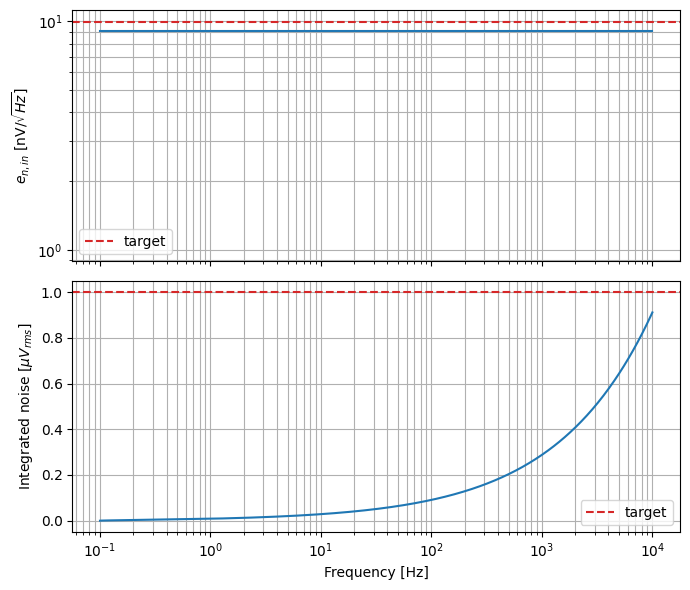

In [6]:
f = np.logspace(-1, 4, 600)
# This plot uses the flat input-referred noise density from the calculation above.
en_density = total_en*np.ones_like(f)
vn_int_curve = np.sqrt(np.maximum(f - f[0], 0))*total_en

fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax[0].loglog(f, en_density*1e9)
ax[0].axhline(en_target*1e9, color="tab:red", linestyle="--", label="target")
ax[0].set_ylabel(r"$e_{n,in}$ [nV/$\sqrt{Hz}$]")
ax[0].grid(True, which="both")
ax[0].legend()

ax[1].semilogx(f, vn_int_curve*1e6)
ax[1].axhline(Vn_rms_target*1e6, color="tab:red", linestyle="--", label="target")
ax[1].set_xlabel("Frequency [Hz]")
ax[1].set_ylabel(r"Integrated noise [$\mu V_{rms}$]")
ax[1].grid(True, which="both")
ax[1].legend()
plt.tight_layout()
plt.show()


The dominant term is the input voltage noise of the first two op amps. The bridge resistance is the second-largest term. The amplifier resistor terms are much smaller because most of the gain is in the first stage, and the second-stage noise is divided by the total gain when referred to the input.



This table is the white-noise budget. It shows that the resistor values and gain split are reasonable: most of the input-referred noise comes from the first two op amps and the bridge resistance. The LTspice noise run below adds the low-frequency noise behavior from the op amp model, so I use that integrated result for the final SNR check.


__4) CMRR and resistor mismatch__

The project gives the worst-case resistor-mismatch CMRR equation

$$
CMRR=G_1\frac{G_2+1}{4\epsilon}.
$$

With $0.1\%$ second-stage resistors, $\epsilon=0.001$. This calculation gives a CMRR above the required $90dB$ for the resistor-matching part of the design.

I also ran the LTspice common-mode AC simulation with the same mismatch condition. The cursor value from that plot is reported in the AC simulation section.


In [7]:
epsilon = 0.001
CMRR = G1*(G2+1)/(4*epsilon)
CMRR_dB = 20*np.log10(CMRR)
Acm = Gtot/CMRR
print(f"CMRR from resistor matching = {CMRR:.0f} V/V = {CMRR_dB:.2f} dB")
print(f"Common-mode gain from resistor matching = {Acm:.5f} V/V = {20*np.log10(Acm):.2f} dB")


CMRR from resistor matching = 37666 V/V = 91.52 dB
Common-mode gain from resistor matching = 0.00265 V/V = -51.54 dB


__5) Component table and power__

I used two dual ADA4528-2 packages. U1 and U3 are the first-stage instrumentation amplifier, U2 is the difference amplifier, and the fourth amplifier buffers $V_{ref}$. The sensor bridge is treated as the given sensor, so the BOM table only includes the electronics components.


In [8]:
bom = pd.DataFrame([
    ["ADA4528-2ARMZ-R7", "dual zero-drift RRIO op amp", 2, 3.54196, "DigiKey TR price, 3000+"],
    ["RP0603BRE07200RL", "200 ohm, 0.1%, 0603 thin film", 1, 0.06463, "R_G"],
    ["RT0603BRB074K99L", "4.99 kohm, 0.1%, 0603 thin film", 2, 0.14761, "R_fp, R_fm"],
    ["RT0603BRE0710KL", "10 kohm, 0.1%, 0603 thin film", 4, 0.04770, "two R1 plus Vref divider"],
    ["RT0603BRD0719K6L", "19.6 kohm, 0.1%, 0603 thin film", 2, 0.03949, "two R2"],
], columns=["part", "description", "qty", "unit_price_USD", "use"])

bom["extended_USD"] = bom["qty"]*bom["unit_price_USD"]
bom.loc[len(bom)] = ["Total", "", "", "", "", bom["extended_USD"].sum()]
bom

,part,description,qty,unit_price_USD,use,extended_USD
0,ADA4528-2ARMZ-R7,dual zero-drift RRIO op amp,2,3.54196,"DigiKey TR price, 3000+",7.08392
1,RP0603BRE07200RL,"200 ohm, 0.1%, 0603 thin film",1,0.06463,R_G,0.06463
2,RT0603BRB074K99L,"4.99 kohm, 0.1%, 0603 thin film",2,0.14761,"R_fp, R_fm",0.29522
3,RT0603BRE0710KL,"10 kohm, 0.1%, 0603 thin film",4,0.0477,two R1 plus Vref divider,0.19080
4,RT0603BRD0719K6L,"19.6 kohm, 0.1%, 0603 thin film",2,0.03949,two R2,0.07898
5,Total,,,,,7.71355


In [9]:
I_bridge = VDD/1e3
I_opamps = 4*1.4e-3     # typical supply current per amplifier from ADA4528-2 datasheet
I_vref_div = VDD/(2*10e3)
P_total = VDD*(I_bridge + I_opamps + I_vref_div)

print(f"Bridge current = {I_bridge*1e3:.2f} mA")
print(f"Op amp supply current = {I_opamps*1e3:.2f} mA")
print(f"Vref divider current = {I_vref_div*1e3:.2f} mA")
print(f"Total current = {(I_bridge + I_opamps + I_vref_div)*1e3:.2f} mA")
print(f"Total power = {P_total*1e3:.2f} mW")


Bridge current = 5.00 mA
Op amp supply current = 5.60 mA
Vref divider current = 0.25 mA
Total current = 10.85 mA
Total power = 54.25 mW



The BOM includes two dual op amp packages because the fourth amplifier is used for the $V_{ref}$ buffer. The intended connection is a 2.5 V divider followed by a unity-gain buffer, and that buffered node drives the lower $R_2$ resistor in the difference amplifier. In the LTspice schematic this node should be shown explicitly as the buffered 2.5 V reference, not only as a net label.


__6) LTspice operating point and transient check__

The balanced LTspice operating-point simulation gives the mid-supply bias:

$$
V_{ip}=V_{in}=V_{out}=V_{ref}=2.500V,
$$

and the internal first-stage / second-stage nodes $V(n001)$ through $V(n006)$ are also $2.500V$. The supply current from the screenshot is

$$
I(V1)=-4.50187mA,
$$

so the simulated three-op-amp core power is

$$
P=5V\times 4.50187mA=22.51mW.
$$

<center><img src="ltSpice/circuit.png" width=760></center>
<br>
<center><b>LTspice transient testbench.</b></center>

<center><img src="ltSpice/phase1_op_schematic.png" width=760></center>
<br>
<center><b>Balanced operating point: all signal nodes are at 2.500 V.</b></center>

For the full-scale transient check, the input plot gives

$$
V(srcp,srcm)\approx -9.96mV \text{ to } +9.98mV \approx 19.94mV_{pp}.
$$

The output plot gives

$$
V_{out}\approx 1.17V \text{ to } 3.67V \approx 2.50V_{pp},
$$

centered at about $2.42V$.

<center><img src="ltSpice/V(srcp,srcm).png" width=760></center>
<br>
<center><b>Input differential transient waveform.</b></center>

<center><img src="ltSpice/v（vout）.png" width=760></center>
<br>
<center><b>Output transient waveform.</b></center>

**Check on this result.** The transient output swing shown here is about $2.50V_{pp}$, while the resistor gain calculation gives $1.995V_{pp}$. That points to the transient testbench/reference setup rather than the selected gain values. The correction is to drive $V_{ref}$ from the buffered 2.5 V node; with that connection, the transient swing should match the $G_1G_2$ calculation. The small-signal differential AC result below is the cleaner gain check for the intended circuit.


__7) AC simulation setup and calculation__

For the differential AC calculation, I used a 1 V differential AC signal around the 2.5 V common-mode level. The low-frequency gain from the selected resistor values is

$$
20\log_{10}(G_{tot})=39.98dB.
$$

The first-stage noise gain is

$$
NG_1=1+\frac{R_f}{R_G}=25.95.
$$

Using the ADA4528 unity-gain crossover around $4MHz$, the first-stage closed-loop pole is

$$
f_{p1}\approx\frac{4MHz}{25.95}=154kHz.
$$

The LTspice cursor values from the AC screenshots are listed below.


fp1 calculation = 154.1 kHz
fp3 calculation = 1.35 MHz
Calculated differential gain at 10 kHz = 39.96 dB
LTspice differential cursor = 39.316913 dB at 10.000000 kHz, phase 8.202961 deg
LTspice common-mode cursor = -51.323300 dB at 10.052 kHz, phase -377.500 deg


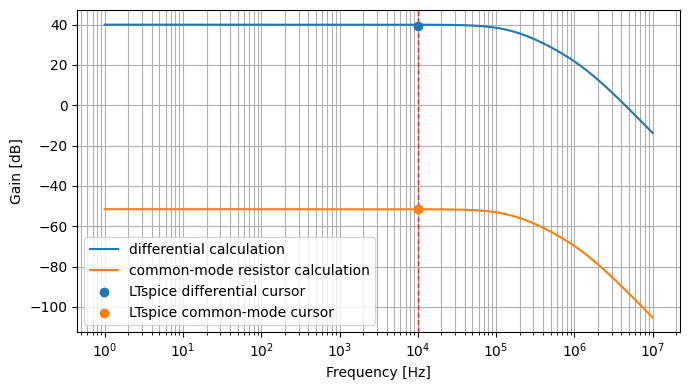

In [10]:
UGB = 4e6
NG1 = 1 + Rfp/RG
NG3 = 1 + G2
fp1 = UGB/NG1
fp3 = UGB/NG3
f = np.logspace(0, 7, 1000)
Ad = Gtot/np.sqrt(1+(f/fp1)**2)/np.sqrt(1+(f/fp3)**2)
Acm_mag = Acm/np.sqrt(1+(f/fp1)**2)/np.sqrt(1+(f/fp3)**2)

ltspice_diff_freq = 10.0e3
ltspice_diff_gain_db = 39.316913
ltspice_diff_phase_deg = 8.202961
ltspice_cm_freq = 10.051761e3
ltspice_cm_gain_db = -51.3233
ltspice_cm_phase_deg = -377.50014

print(f"fp1 calculation = {fp1/1e3:.1f} kHz")
print(f"fp3 calculation = {fp3/1e6:.2f} MHz")
print(f"Calculated differential gain at 10 kHz = {20*np.log10(np.interp(1e4, f, Ad)):.2f} dB")
print(f"LTspice differential cursor = {ltspice_diff_gain_db:.6f} dB at {ltspice_diff_freq/1e3:.6f} kHz, phase {ltspice_diff_phase_deg:.6f} deg")
print(f"LTspice common-mode cursor = {ltspice_cm_gain_db:.6f} dB at {ltspice_cm_freq/1e3:.3f} kHz, phase {ltspice_cm_phase_deg:.3f} deg")

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(f, 20*np.log10(Ad), label="differential calculation")
ax.semilogx(f, 20*np.log10(Acm_mag), label="common-mode resistor calculation")
ax.scatter([ltspice_diff_freq], [ltspice_diff_gain_db], color="tab:blue", zorder=3, label="LTspice differential cursor")
ax.scatter([ltspice_cm_freq], [ltspice_cm_gain_db], color="tab:orange", zorder=3, label="LTspice common-mode cursor")
ax.axvline(10e3, color="tab:red", linestyle="--", linewidth=1)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Gain [dB]")
ax.grid(True, which="both")
ax.legend()
plt.tight_layout()
plt.show()


From the LTspice AC screenshots:

**Differential frequency response.** The plot uses `dB(V(vout)/V(srcp,srcm))`. The cursor reads

$$
f=10.000kHz, \qquad |A_d|=39.316913dB, \qquad \angle A_d=8.202961^\circ.
$$

**Common-mode frequency response with worst-case second-stage mismatch.** The plot uses `dB(V(vout)/V(vcm))`. The cursor reads

$$
f=10.051761kHz, \qquad |A_{cm}|=-51.3233dB, \qquad \angle A_{cm}=-377.50014^\circ.
$$

For the common-mode case I use the LTspice cursor value, $-51.3233dB$ at $10.051761kHz$, as the simulation result.

<center><img src="ltSpice/df.png" width=760></center>
<br>
<center><b>Differential AC simulation testbench.</b></center>

<center><img src="ltSpice/phase1_diff_ac.png" width=760></center>
<br>
<center><b>Differential AC result: 39.316913 dB at 10 kHz.</b></center>

<center><img src="ltSpice/Common-mode AC simulation with mismatch.png" width=760></center>
<br>
<center><b>Common-mode AC simulation testbench with worst-case resistor mismatch.</b></center>

<center><img src="ltSpice/phase1_cm_ac.png" width=760></center>
<br>
<center><b>Common-mode AC result: -51.3233 dB at 10.051761 kHz.</b></center>

From the two LTspice AC cursor values at 10 kHz,

$$
CMRR_{10kHz}=A_d-A_{cm}=39.3169-(-51.3233)=90.64dB.
$$

This agrees with the hand calculation, which gives $91.52dB$ for 0.1% second-stage matching. The resistor tolerance choice is therefore tight enough for the 90 dB CMRR target. The corrected schematic should use the buffered $V_{ref}$ node for this same AC run.


__8) LTspice noise result__

The noise simulation uses

```text
.noise V(vout) Vdiff dec 100 0.1 10k
```

where `Vdiff` is the 1 V differential AC test source used at the input. In LTspice, `V(inoise)` is the input-referred noise for this source.

The cursor in the saved noise plot is at

$$
f=10kHz, \qquad V(inoise)=9.1862207nV/\sqrt{Hz}.
$$

The LTspice error log reports the integrated input-referred noise as

$$
V_{n,in}(0.1Hz\text{ to }10kHz)=9.4965407\mu V_{rms}.
$$

<center><img src="ltSpice/Noise simulation.png" width=760></center>
<br>
<center><b>Noise simulation testbench.</b></center>

<center><img src="ltSpice/phase1_noise_density.png" width=760></center>
<br>
<center><b>Input-referred noise cursor: 9.1862207 nV/sqrt(Hz) at 10 kHz.</b></center>


**Noise check.** The 10 kHz density is close to the hand budget and is below the flat-density target of about $9.99nV/\sqrt{Hz}$. The larger number is the integrated result from the LTspice model: $9.4965\mu V_{rms}$ from 0.1 Hz to 10 kHz. That means the limiting part of this simulation is the low-frequency noise, not the 10 kHz white-noise floor.

Using the LTspice integrated value,

$$
SNR=20\log_{10}\left(\frac{7.071mV}{9.4965\mu V}\right)=57.4dB.
$$

To meet the 77 dB SNR target, the input-stage op amp has to be selected from the 0.1 Hz to 10 Hz noise spec as well as the 10 kHz voltage-noise density. The gain split and resistor values can stay the same; the change needed is to use a lower low-frequency-noise input op amp model for the first stage, then rerun the same `.noise` command and check that the integrated input-referred noise is below $0.999\mu V_{rms}$.
